combined PAC analysis. joins the temporal classifier (nb 05, all_bylines_bands.csv) and the content classifier (nb 06, content_classifier_per_advertiser.csv) per-advertiser, computes a combined PAC-likeness score, and produces two tables for the report:

1. top 20 advertisers by total spend, with their three metrics (band / EC index, pre-election content score) and the combined PAC score.
2. top 10 PACs (highest combined score), with their top 3 ads by spend each.

the combined score is `pac_score = ec_index * mean_prob_pre` --- a multiplicative AND composite that is high only when both temporal concentration and pre-election content density are high together.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, expr, coalesce, substring, first,
    sum as spark_sum, count as spark_count,
    row_number, desc,
)
from pyspark.sql.window import Window
import pandas as pd
import numpy as np

spark = SparkSession.builder \
    .appName('FB_API_combined_pacs') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/18 05:14:06 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
V3_PATH        = '/user/s3348393/main/preprocessing/v3/parquet'
BANDS_CSV      = '../data/all_bylines_bands.csv'
CONTENT_CSV    = '../data/content_classifier_per_advertiser.csv'

TOP_20_OUT_CSV     = '../data/top_20_with_metrics.csv'
TOP_PACS_OUT_CSV   = '../data/top_10_pacs_with_top_ads.csv'

TOP_N_SPENDERS    = 20

# A PAC must clear both classifier thresholds (top-right quadrant of the
# pac-likeness space). Top 10 PACs are then ranked by total spend.
EC_INDEX_MIN      = 0.5
MEAN_PROB_PRE_MIN = 0.5
TOP_N_PACS        = 10
TOP_N_ADS_PER_PAC = 3

load temporal and content scores per advertiser, join them, compute the combined PAC score.

In [3]:
bands_df   = pd.read_csv(BANDS_CSV)
content_df = pd.read_csv(CONTENT_CSV)

print(f'temporal classifier rows: {len(bands_df):,}')
print(f'content classifier rows:  {len(content_df):,}')

# Inner-join on bylines --- only advertisers that survived both classifiers
metrics = (bands_df[['bylines', 'band', 'persistence', 'ec_index']]
    .merge(
        content_df[['bylines', 'mean_prob_pre',
                    'mean_election_prob_weighted', 'total_spend']],
        on='bylines', how='inner'
    ))

# Combined PAC-likeness score: strict-AND multiplicative composite
metrics['pac_score'] = metrics['ec_index'] * metrics['mean_prob_pre']

print(f'\njoined metrics: {len(metrics):,} advertisers')
print(f'pac_score range: {metrics["pac_score"].min():.3f} - {metrics["pac_score"].max():.3f}')

temporal classifier rows: 567
content classifier rows:  2,439

joined metrics: 567 advertisers
pac_score range: 0.001 - 0.914


table 1: top 20 advertisers by total spend, with their three metrics and the combined PAC score.

In [4]:
top20_metrics = (metrics
    .sort_values('total_spend', ascending=False)
    .head(TOP_N_SPENDERS)
    .reset_index(drop=True))

display_cols = ['bylines', 'total_spend', 'band',
                'ec_index', 'mean_prob_pre', 'pac_score']

print(f'Top {TOP_N_SPENDERS} advertisers by total spend:')
display(top20_metrics[display_cols])

top20_metrics[display_cols].to_csv(TOP_20_OUT_CSV, index=False)
print(f'\nWrote {TOP_20_OUT_CSV}')

Top 20 advertisers by total spend:


,bylines,total_spend,band,ec_index,mean_prob_pre,pac_score
0,Greenpeace Australia Pacific,1556769.5,ongoing,0.466242,0.093489,0.043589
1,Amnesty International Australia,854819.0,election_only,0.441121,0.594555,0.262271
2,Solutions for Australia,656140.5,election_only,0.852070,0.471664,0.401890
3,Australian Conservation Foundation,644985.5,transitional,0.538804,0.243394,0.131142
4,Climate 200,629674.5,election_only,0.499911,0.847031,0.423440
5,Thrive By Five,612850.0,transitional,0.648939,0.670353,0.435018
6,Australian Unions,543427.5,ongoing,0.635139,0.556150,0.353233
7,Australia for UNHCR,514934.5,transitional,0.610156,0.345543,0.210835
8,Future Super,402754.0,ongoing,0.488685,0.006898,0.003371
9,Plan International Australia,378201.5,ongoing,0.598608,0.290985,0.174186



Wrote ../data/top_20_with_metrics.csv


table 2: top 10 PACs by combined score, with each PAC's top 3 ads by spend.

In [5]:
# Define a PAC as ec_index > 0.5 AND mean_prob_pre > 0.5 (the top-right
# quadrant of the PAC-likeness scatter) AND band != 'ongoing'. The
# 'ongoing' band by definition means post-election spend matches
# pre-election spend, which contradicts the PAC definition --- so we
# exclude it even when the content classifier scores high (this catches
# year-round advocates whose vocabulary overlaps with electoral
# language, e.g. unions, charities).
pacs = (metrics
    .query('ec_index > @EC_INDEX_MIN '
           'and mean_prob_pre > @MEAN_PROB_PRE_MIN '
           "and band != 'ongoing'")
    .sort_values('total_spend', ascending=False)
    .reset_index(drop=True))

print(f'{len(pacs)} advertisers meet the PAC definition '
      f'(ec_index > {EC_INDEX_MIN}, mean_prob_pre > {MEAN_PROB_PRE_MIN}, '
      f"band != 'ongoing').")

top_pacs = pacs.head(TOP_N_PACS).reset_index(drop=True)
top_pac_bylines = top_pacs['bylines'].tolist()

print(f'\nTop {min(TOP_N_PACS, len(pacs))} PACs by spend:')
display(top_pacs[['bylines', 'total_spend', 'band', 'ec_index',
                  'mean_prob_pre', 'pac_score']])

# Pull each PAC's top 3 ads from v3 (by total spend per unique creative title)
def first_non_empty(col_name):
    return expr(f"filter({col_name}, x -> x is not null and length(x) > 0)[0]")

ad_title = coalesce(
    first_non_empty('creative_link_titles'),
    substring(first_non_empty('creative_bodies'), 1, 80),
)

v3 = spark.read.parquet(V3_PATH).filter(col('match_type').isNull())

ad_spend = (v3
    .filter(col('bylines').isin(top_pac_bylines) & col('spend_mid').isNotNull())
    .withColumn('ad_title', ad_title)
    .filter(col('ad_title').isNotNull())
    .groupBy('bylines', 'ad_title')
    .agg(
        spark_sum('spend_mid').alias('total_spend'),
        spark_count('*').alias('n_runs'),
        first('ad_snapshot_url').alias('example_url'),
    ))

w = Window.partitionBy('bylines').orderBy(desc('total_spend'))
top_pac_ads = (ad_spend
    .withColumn('rank', row_number().over(w))
    .filter(col('rank') <= TOP_N_ADS_PER_PAC)
    .orderBy('bylines', 'rank')
    .toPandas())

# Preserve PAC ranking order
top_pac_ads['_byline_order'] = top_pac_ads['bylines'].map(
    {b: i for i, b in enumerate(top_pac_bylines)})
top_pac_ads = (top_pac_ads
    .sort_values(['_byline_order', 'rank'])
    .drop(columns='_byline_order')
    .reset_index(drop=True))

print(f'\n{len(top_pac_ads)} rows: top {TOP_N_ADS_PER_PAC} ads for each of the top {len(top_pacs)} PACs.')

97 advertisers meet the PAC definition (ec_index > 0.5, mean_prob_pre > 0.5, band != 'ongoing').

Top 10 PACs by spend:


,bylines,total_spend,band,ec_index,mean_prob_pre,pac_score
0,Thrive By Five,612850.0,transitional,0.648939,0.670353,0.435018
1,Smart Voting,302671.5,election_only,0.938735,0.836677,0.785418
2,Australian Christian Lobby,274256.5,transitional,0.629040,0.863279,0.543037
3,Australian Education Union,253022.5,election_only,0.802521,0.982732,0.788663
4,It's Not A Race,221677.5,election_only,0.828475,0.530003,0.439094
5,GetUp!,203838.0,election_only,0.767506,0.776768,0.596174
6,ABC Friends,146068.0,election_only,0.740500,0.794177,0.588088
7,Australian Automobile Association,128001.5,election_only,0.699492,0.870148,0.608662
8,TAB,93490.0,election_only,0.863349,0.767769,0.662852
9,Cancer Council SA,81084.0,transitional,0.511264,0.604354,0.308984



30 rows: top 3 ads for each of the top 10 PACs.


visualisations. (1) a PAC-likeness scatter showing where every advertiser sits in temporal-classifier $\times$ content-classifier space, with the top 20 spenders highlighted and the top 10 PACs in bold. (2) a horizontal bar chart of the top 10 PACs ranked by combined PAC score.

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


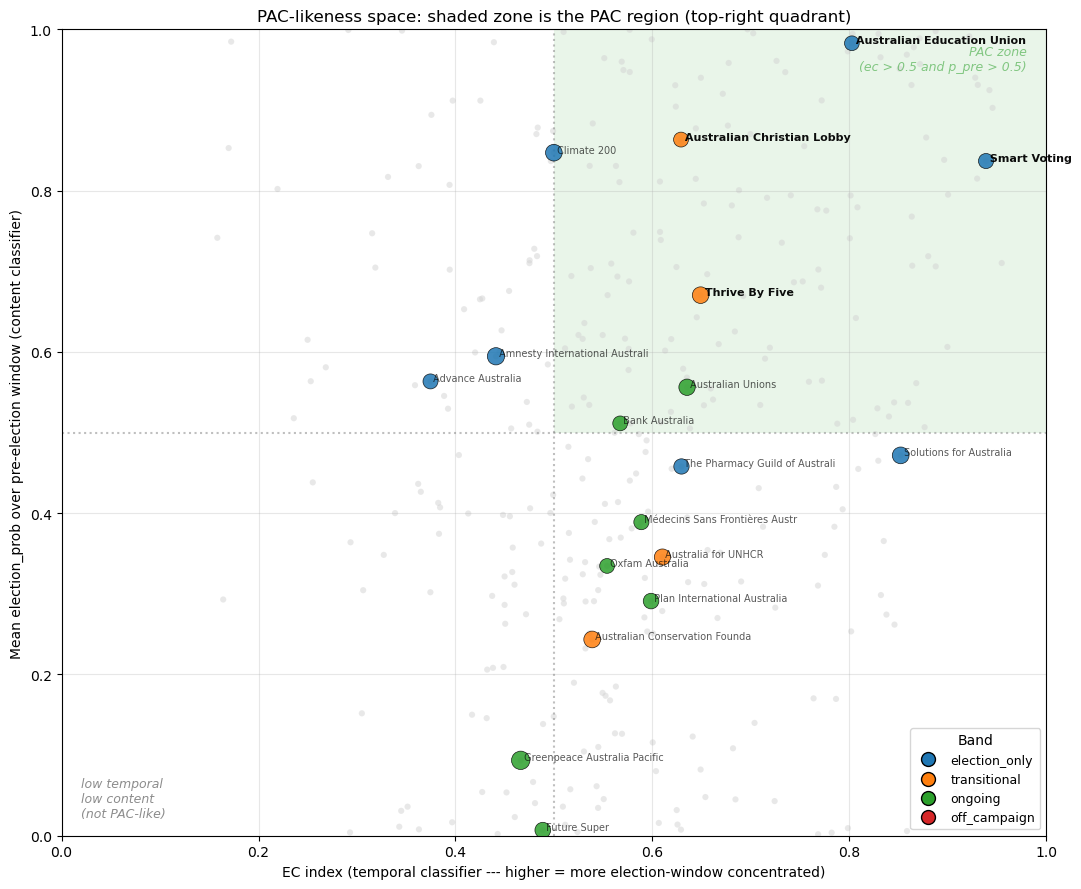

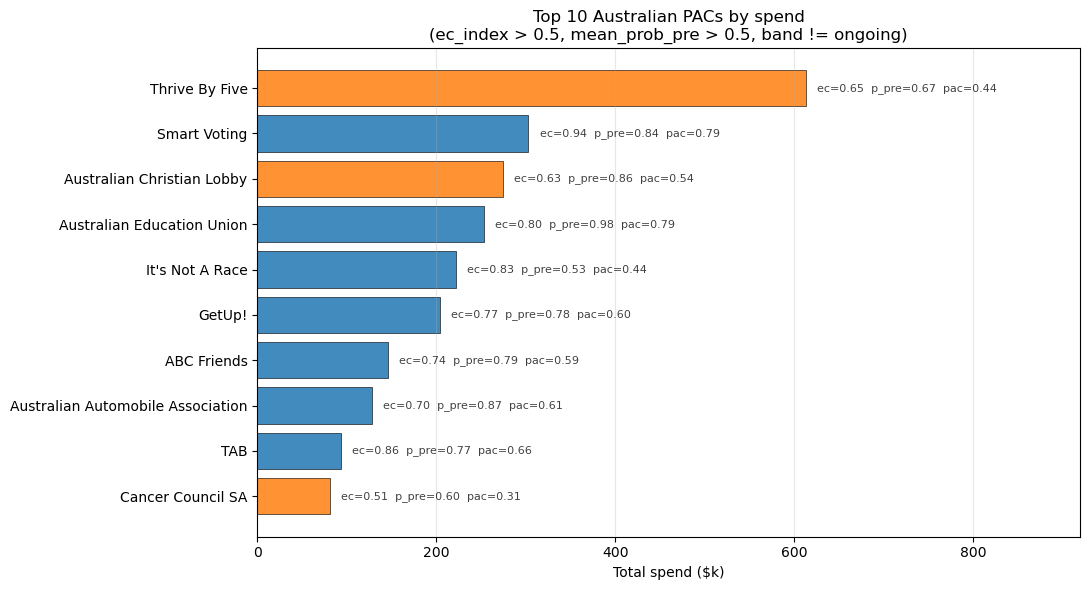

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

BAND_COLORS = {
    'election_only': '#1f77b4',
    'transitional':  '#ff7f0e',
    'ongoing':       '#2ca02c',
    'off_campaign':  '#d62728',
}

# === Viz 1: PAC-likeness scatter (temporal x content) ===
# Background: all advertisers as small grey dots.
# Foreground: top 20 spenders sized by log spend, coloured by band.
# Top-right quadrant (ec_index > 0.5, mean_prob_pre > 0.5) shaded as PAC zone.
# PACs identified by the threshold filter labelled in bold.

fig, ax = plt.subplots(figsize=(11, 9))

# Shade the PAC quadrant
ax.add_patch(Rectangle((EC_INDEX_MIN, MEAN_PROB_PRE_MIN),
                       1 - EC_INDEX_MIN, 1 - MEAN_PROB_PRE_MIN,
                       facecolor='#2ca02c', alpha=0.10,
                       edgecolor='none', zorder=0))

ax.scatter(metrics['ec_index'], metrics['mean_prob_pre'],
           s=20, c='lightgray', alpha=0.5, edgecolor='none', zorder=1)

top20_colours = top20_metrics['band'].map(BAND_COLORS).fillna('#888888')
spend_sizes = (np.log10(top20_metrics['total_spend'].fillna(1)) - 4).clip(lower=0.5) * 80

ax.scatter(top20_metrics['ec_index'], top20_metrics['mean_prob_pre'],
           s=spend_sizes, c=top20_colours, alpha=0.85,
           edgecolor='black', linewidth=0.5, zorder=3)

top_pac_set = set(top_pacs['bylines'])
texts = []
for _, row in top20_metrics.iterrows():
    is_pac = row['bylines'] in top_pac_set
    texts.append(ax.text(
        row['ec_index'], row['mean_prob_pre'],
        ' ' + row['bylines'][:30],
        fontsize=8 if is_pac else 7,
        fontweight='bold' if is_pac else 'normal',
        alpha=0.95 if is_pac else 0.65,
        zorder=5 if is_pac else 4,
    ))

try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.6))
except ImportError:
    pass

ax.axhline(MEAN_PROB_PRE_MIN, color='gray', linestyle=':', alpha=0.5)
ax.axvline(EC_INDEX_MIN, color='gray', linestyle=':', alpha=0.5)

ax.text(0.98, 0.98, 'PAC zone\n(ec > 0.5 and p_pre > 0.5)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, alpha=0.55, fontstyle='italic', color='#2ca02c')
ax.text(0.02, 0.02, 'low temporal\nlow content\n(not PAC-like)',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=9, alpha=0.45, fontstyle='italic')

band_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='w',
           markerfacecolor=c, markeredgecolor='black', markersize=10, label=b)
    for b, c in BAND_COLORS.items()
]
ax.legend(handles=band_handles, loc='lower right', fontsize=9, title='Band')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('EC index (temporal classifier --- higher = more election-window concentrated)')
ax.set_ylabel('Mean election_prob over pre-election window (content classifier)')
ax.set_title('PAC-likeness space: shaded zone is the PAC region (top-right quadrant)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# === Viz 2: Top PACs ranked by spend (bar length = total spend) ===

fig, ax = plt.subplots(figsize=(11, 6))

top_pacs_sorted = top_pacs.sort_values('total_spend', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(top_pacs_sorted))
colours = top_pacs_sorted['band'].map(BAND_COLORS).fillna('#888888')

spend_k = top_pacs_sorted['total_spend'] / 1000
ax.barh(y_pos, spend_k, color=colours,
        edgecolor='black', linewidth=0.5, alpha=0.85)

for i, (_, row) in enumerate(top_pacs_sorted.iterrows()):
    ax.text((row['total_spend'] / 1000) + 5, i,
            f'  ec={row["ec_index"]:.2f}  p_pre={row["mean_prob_pre"]:.2f}  pac={row["pac_score"]:.2f}',
            va='center', fontsize=8, alpha=0.75)

ax.set_yticks(y_pos)
ax.set_yticklabels([b[:35] for b in top_pacs_sorted['bylines']])
ax.set_xlim(0, spend_k.max() * 1.5)
ax.set_xlabel('Total spend ($k)')
ax.set_title(f'Top {len(top_pacs)} Australian PACs by spend\n(ec_index > {EC_INDEX_MIN}, mean_prob_pre > {MEAN_PROB_PRE_MIN}, band != ongoing)')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

per-PAC display and export.

In [7]:
for byline in top_pac_bylines:
    sub = top_pac_ads[top_pac_ads['bylines'] == byline]
    pac_row = top_pacs[top_pacs['bylines'] == byline].iloc[0]
    print(f'\n=== {byline}  (pac_score={pac_row["pac_score"]:.3f}, '
          f'${pac_row["total_spend"]:,.0f} total, band={pac_row["band"]}) ===')
    if sub.empty:
        print('(no ads matched filter)')
        continue
    display(sub[['rank', 'ad_title', 'total_spend', 'n_runs']])

# Join PAC-level scores onto the ad-level rows for the export
top_pac_ads_export = top_pac_ads.merge(
    top_pacs[['bylines', 'pac_score', 'band']],
    on='bylines', how='left')

out_cols = ['bylines', 'pac_score', 'band', 'rank', 'ad_title',
            'total_spend', 'n_runs', 'example_url']
import re
top_pac_ads_export['example_url'] = top_pac_ads_export['example_url'].apply(
    lambda u: re.sub(r'(?<=[?&])access_token=[^&]*&?', '', u).rstrip('?&') if pd.notna(u) else u
)
top_pac_ads_export[out_cols].to_csv(TOP_PACS_OUT_CSV, index=False)
print(f'\nWrote {TOP_PACS_OUT_CSV}')


=== Thrive By Five  (pac_score=0.435, $612,850 total, band=transitional) ===


,rank,ad_title,total_spend,n_runs
0,1,Let's make early learning and childcare fair f...,128700.5,399
1,2,Country kids shouldn’t be left behind.,106430.5,39
2,3,Families should be able to choose what works f...,98973.5,53



=== Smart Voting  (pac_score=0.785, $302,672 total, band=election_only) ===


,rank,ad_title,total_spend,n_runs
3,1,"Since the Coalition took power, prices have sk...",119245.5,9
4,2,We can’t afford three more years of economic b...,27993.0,14
5,3,Scott Morrison promised he’d create a national...,19696.5,7



=== Australian Christian Lobby  (pac_score=0.543, $274,256 total, band=transitional) ===


...


=== TAB  (pac_score=0.663, $93,490 total, band=election_only) ===


,rank,ad_title,total_spend,n_runs
24,1,Australian Election Markets,59093.5,13
25,2,Australian Election Markets,32498.5,3
26,3,"Democracy snags are good, but Bunnings snags a...",649.5,1



=== Cancer Council SA  (pac_score=0.309, $81,084 total, band=transitional) ===


,rank,ad_title,total_spend,n_runs
27,1,Choose water instead,8947.5,5
28,2,Don't Miss Your Chance To Get A FREE Host Kit!,4797.0,6
29,3,Make a hairy sacrifice,4197.0,6



Wrote ../data/top_10_pacs_with_top_ads.csv
